# Lecture 9 Lab — Anatomy of an Agent

## Watch the agentic loop run, then design and dispatch your own agents

T2a and T3b argued four things. This lab makes all four checkable:

1. **A "session" is a list**, re-sent in full on every turn — not a connection.
2. **The loop is small**: model → tool call → your code → result → model.
3. **"How many agents?"** is a budget question, not a software question.
4. **Dispatch is a tool call** the model makes by reading prose *you* wrote.

**Part A (this notebook)** runs entirely offline — no API key, no network, no
GPU, no cost. The model is stubbed by a `ScriptedModel` that replays fixed
responses, so the loop around it is the real thing and behaves deterministically.

**Part B (`TERMINAL_WALKTHROUGH.md`)** is where you dispatch real agents from
your terminal and watch it happen.

> **Why stub the model?** Because the loop is the lesson. A live model would
> make every run different and cost money, and would hide the very mechanics
> we are trying to expose.

## Step 0 — Quick environment check (run me first)

In [1]:
# Quick environment check -- standard library, numpy, matplotlib only
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "agent_lab.py").exists():
    raise RuntimeError(
        "Start this notebook from the Lec09_Agent_Lab folder (it contains agent_lab.py)."
    )
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import agent_lab

print(f"python      : {sys.version.split()[0]}")
print(f"numpy       : {np.__version__}")
print(f"working dir : {ROOT.name}")
for name in agent_lab.HARNESSES:
    found = 'found' if agent_lab.harness_available(name) else 'not found'
    print(f"{name + ' CLI':12s}: {found}")
print("(Part A needs none of them. For Part B, run: python3 scripts/setup_check.py --live)")
print("\nenvironment ready -- every cell below runs with no API key and no network.")

python      : 3.9.21
numpy       : 1.24.4
working dir : Lec09_Agent_Lab
claude CLI  : found
gemini CLI  : found
codex CLI   : found
(Part A needs none of them. For Part B, run: python3 scripts/setup_check.py --live)

environment ready -- every cell below runs with no API key and no network.


## Step 1 — The session is a list, not a connection

The Messages API is **stateless**. There is no open connection and no
server-side memory of you. What feels like memory is you re-sending the whole
conversation every turn.

Build one by hand and watch it grow.

In [2]:
from agent_lab import count_tokens, conversation_tokens

messages = [{"role": "user", "content": "Solve the household problem and report r."}]
print(f"turn 1: {len(messages)} message(s), {conversation_tokens(messages):>4} tokens sent")

# The model replies asking for a tool; that reply goes back into the list.
messages.append({"role": "assistant",
                 "content": [{"type": "tool_use", "id": "t1",
                              "name": "discount_to_rate", "input": {"beta": 0.96}}]})
messages.append({"role": "user",
                 "content": [{"type": "tool_result", "tool_use_id": "t1",
                              "content": "0.041667"}]})
print(f"turn 2: {len(messages)} message(s), {conversation_tokens(messages):>4} tokens sent")

messages.append({"role": "assistant",
                 "content": [{"type": "text", "text": "The steady-state rate is 4.17%."}]})
messages.append({"role": "user", "content": "Now check the budget constraint at a=2."})
print(f"turn 3: {len(messages)} message(s), {conversation_tokens(messages):>4} tokens sent")

print("\nNothing was stored anywhere. 'Memory' is this list, and you pay to resend it.")

turn 1: 1 message(s),   18 tokens sent
turn 2: 3 message(s),   74 tokens sent
turn 3: 5 message(s),  116 tokens sent

Nothing was stored anywhere. 'Memory' is this list, and you pay to resend it.


> **✏️ Your turn:** append two more exchanges and re-run. The token count is
> the *whole list*, not the new message. Now predict: if a session runs for 60
> turns, does cost grow linearly or faster than linearly? Step 4 measures it.

## Step 2 — A tool is code plus a schema

The model never runs your code. It emits a **name and arguments**; your harness
looks up the function and runs it. The schema is the contract.

In [3]:
from agent_lab import Tool, ToolRegistry
import json

def discount_to_rate(beta: float) -> str:
    "Steady-state interest rate implied by impatience: r = 1/beta - 1."
    return f"{1.0 / beta - 1.0:.6f}"

def consumption(a: float, z: float, a_next: float, r: float = 0.04, w: float = 1.0) -> str:
    "Budget constraint: c = (1+r)a + wz - a'."
    return f"{(1.0 + r) * a + w * z - a_next:.6f}"

def crra_utility(c: float, sigma: float = 2.0) -> str:
    "CRRA utility, correctly guarded against infeasible consumption."
    if c <= 0:
        return "-inf (infeasible: consumption must be strictly positive)"
    if abs(sigma - 1.0) < 1e-12:
        return f"{np.log(c):.6f}"
    return f"{c ** (1.0 - sigma) / (1.0 - sigma):.6f}"

registry = ToolRegistry([
    Tool("discount_to_rate", "Steady-state r implied by beta.",
         {"type": "object", "properties": {"beta": {"type": "number"}},
          "required": ["beta"]}, discount_to_rate),
    Tool("consumption", "Consumption from the budget constraint.",
         {"type": "object",
          "properties": {k: {"type": "number"} for k in ("a", "z", "a_next", "r", "w")},
          "required": ["a", "z", "a_next"]}, consumption),
    Tool("crra_utility", "CRRA utility of consumption c.",
         {"type": "object",
          "properties": {"c": {"type": "number"}, "sigma": {"type": "number"}},
          "required": ["c"]}, crra_utility),
])

print("tools the model will be shown:", registry.names())
print("\nthe exact JSON sent in tools=[...]:")
print(json.dumps(registry.to_api_list()[1], indent=2))

tools the model will be shown: ['consumption', 'crra_utility', 'discount_to_rate']

the exact JSON sent in tools=[...]:
{
  "name": "crra_utility",
  "description": "CRRA utility of consumption c.",
  "input_schema": {
    "type": "object",
    "properties": {
      "c": {
        "type": "number"
      },
      "sigma": {
        "type": "number"
      }
    },
    "required": [
      "c"
    ]
  }
}


Note `crra_utility` refuses `c <= 0`. Hold that thought — the solver you review
in Part B does **not**, and that single omission is why it prefers bankruptcy.

## Step 3 — Run the loop

`agent_lab.run_agent` is the twenty-line loop from the slide, with only the
model stubbed. Watch each turn: what was sent, what the model asked for, what
your code returned.

In [4]:
from agent_lab import ScriptedModel, Response, tool_use_block, text_block, run_agent

# The scripted "model": three turns. Turns 1-2 call tools, turn 3 answers.
script = [
    Response(content=[text_block("I need the steady-state rate first."),
                      tool_use_block("t1", "discount_to_rate", {"beta": 0.96})],
             stop_reason="tool_use"),
    Response(content=[tool_use_block("t2", "consumption",
                                     {"a": 2.0, "z": 1.0, "a_next": 2.1, "r": 0.041667}),
                      tool_use_block("t3", "crra_utility", {"c": 0.983334})],
             stop_reason="tool_use"),          # <- TWO calls in one turn
    Response(content=[text_block("r = 4.17%; at a=2, a'=2.1 leaves c = 0.98 and u = -1.02.")],
             stop_reason="end_turn"),
]

model = ScriptedModel(script=script)
trace = run_agent(model, registry,
                  system="You are a computational macroeconomist.",
                  user_prompt="At beta=0.96, what is r, and is a'=2.1 affordable at a=2, z=1?")

print(f"\nfinished in {trace['turns']} turns")
print("final answer:", trace["final_text"])

  turn 1: sent    23 tok | stop=tool_use  | 1 tool call(s) | "I need the steady-state rate first."
       -> discount_to_rate({'beta': 0.96}) = 0.041667
  turn 2: sent   100 tok | stop=tool_use  | 2 tool call(s)
       -> consumption({'a': 2.0, 'z': 1.0, 'a_next': 2.1, 'r': 0.041667}) = 0.983334
       -> crra_utility({'c': 0.983334}) = -1.016948
  turn 3: sent   212 tok | stop=end_turn  | 0 tool call(s) | "r = 4.17%; at a=2, a'=2.1 leaves c = 0.98 and u "

finished in 3 turns
final answer: r = 4.17%; at a=2, a'=2.1 leaves c = 0.98 and u = -1.02.


Two things to notice:

- **Turn 2 issued two tool calls at once.** Both results go back in a *single*
  user message. Splitting them across two messages would be a protocol error.
- **The loop ended because `stop_reason` changed**, not because a counter ran
  out. That distinction is exactly what the flawed solver in Part B gets wrong.

> **✏️ Your turn:** add a fourth scripted turn that calls a tool that does not
> exist. The registry returns an error *as a tool result* rather than raising —
> re-run and see. Why must a failed tool still return a result?

## Step 4 — The cost curve: why long sessions get expensive

Each turn adds a little, but re-sends everything. Cost is the **area under the
list**, so it grows with the square of the turn count.

what the model was shown each turn:
  turn 1:    23 tokens, 1 tool call(s)
  turn 2:   100 tokens, 2 tool call(s)
  turn 3:   212 tokens, 0 tool call(s)


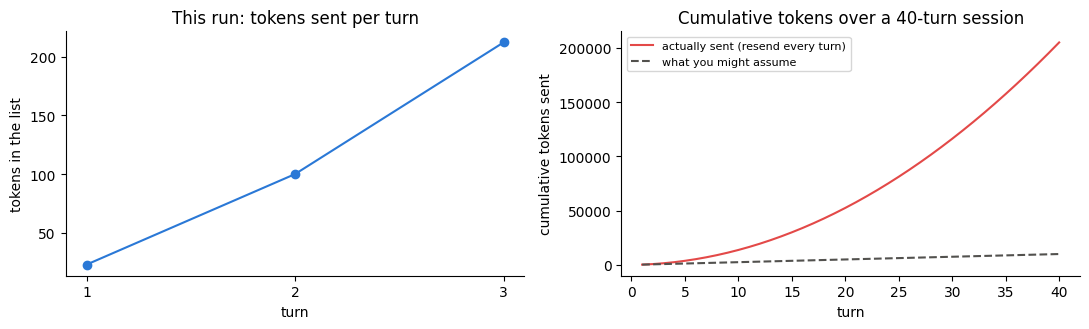

after 40 turns: 205,000 tokens sent, vs 10,000 if each turn cost only its own text (20.5x)


In [5]:
hist = trace["history"]
print("what the model was shown each turn:")
for h in hist:
    print(f"  turn {h['turn']}: {h['tokens_sent']:>5} tokens, {h['tool_calls']} tool call(s)")

turns = list(range(1, 41))
cumulative = agent_lab.resend_cost(len(turns), new_tokens_per_turn=250)
naive = [250 * t for t in turns]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot([h["turn"] for h in hist], [h["tokens_sent"] for h in hist],
             marker="o", color="#2a78d6")
axes[0].set_title("This run: tokens sent per turn")
axes[0].set_xlabel("turn"); axes[0].set_ylabel("tokens in the list")
axes[0].set_xticks([h["turn"] for h in hist])

axes[1].plot(turns, cumulative, label="actually sent (resend every turn)", color="#e34948")
axes[1].plot(turns, naive, label="what you might assume", color="#52514e", ls="--")
axes[1].set_title("Cumulative tokens over a 40-turn session")
axes[1].set_xlabel("turn"); axes[1].set_ylabel("cumulative tokens sent")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(f"after 40 turns: {cumulative[-1]:,} tokens sent, "
      f"vs {naive[-1]:,} if each turn cost only its own text "
      f"({cumulative[-1] / naive[-1]:.1f}x)")

This is the whole reason compaction (T5c) exists, and the reason a sub-agent
with a fresh list is worth paying for (T5b). It is one fact with three
consequences.

## Step 4b (optional) — Replay a real run through the same loop

T2a traced one real Claude Code run, call by call: *GDP growth by party*. The
recording is in `transcripts/`. `load_transcript` turns it back into a script
(the model's recorded responses) and a registry that answers each tool call
with the result the real run got. The loop is the same `run_agent` as in
Step 3. Nothing is fetched, written, or executed.

The recording truncates long inputs and results and omits the harness's
bundled skill files, so its token counts would badly understate the real run.
Read this replay for its **structure**, not its cost.


call  tool calls              said
   1  ToolSearch             I'll gather real GDP growth data and White House party control, 
   2  Skill                  
   3  WebSearch, WebSearch   
   4  WebFetch               Search results are inconsistent, so let me pull directly from a 
   5  WebFetch               
   6  WebFetch               That data looks inconsistent with known figures (e.g., 2020 COVI
   7  Read                   
   8  Read                   
   9  Bash                   ERROR 
  10  Read                   
  11  Read                   
  12  Write                  Now I have verified, official FRED data (BEA series A191RL1A225N
  13  Edit                   I introduced a JS syntax bug (`marginRight: undefined` inside a 
  14  Bash                   
  15  Bash                   ERROR 
  16  Read                   
  17  Skill                  This looks correct. The file is self-contained (data, chart, tab
  18  Read                   
  19  Bash                   

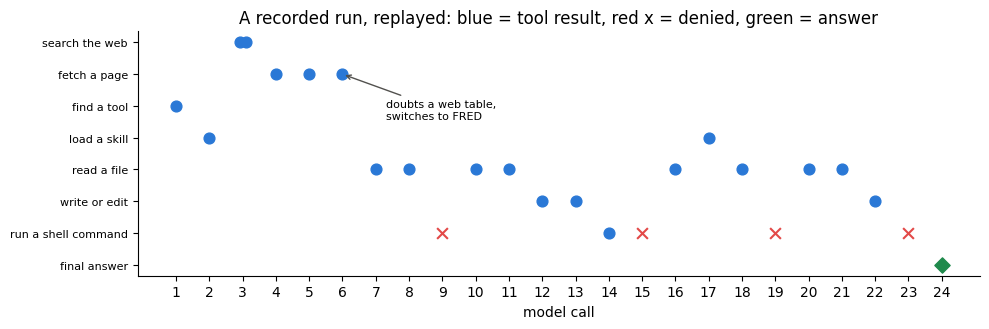

In [6]:
from collections import Counter
from agent_lab import load_transcript

recorded, recorded_tools, meta = load_transcript(
    "transcripts/gdp_by_party_claude-code-2.1.270_2026-09-12.jsonl")
replay = run_agent(recorded, recorded_tools,
                   system="(the harness's system prompt is not in the recording)",
                   user_prompt="Get US real GDP growth since 2000. Get which party held the White "
                               "House over the same period. Then plot and rationalize how party "
                               "affiliation affects GDP growth.",
                   max_turns=40, trace=False)

# one results message per model call that used tools, in order
results = [m["content"] for m in replay["messages"]
           if m["role"] == "user" and isinstance(m["content"], list)]
print("call  tool calls              said")
for k, resp in enumerate(recorded.script, start=1):
    names = [b["name"] for b in resp.content if b["type"] == "tool_use"]
    said = " ".join(b["text"] for b in resp.content if b["type"] == "text")
    denied = k <= len(results) and any(r["is_error"] for r in results[k - 1])
    print(f"{k:>4}  {', '.join(names) or '(final answer)':<22} {'ERROR ' if denied else ''}{said[:64]}")

tools_used = Counter(b["name"] for r in recorded.script for b in r.content if b["type"] == "tool_use")
n_errors = sum(r["is_error"] for msg in results for r in msg)
print(f"\n{replay['turns']} model calls, {sum(tools_used.values())} tool calls, "
      f"{n_errors} errors handed back as tool results")
print("tools:", dict(tools_used))
print(f"the harness's own summary: num_turns = {meta['num_turns']}, "
      f"{meta['duration_ms'] / 1000:.0f} s, ${meta['total_cost_usd']:.2f}")

# the run as a timeline: what kind of action, at which model call
kind = {"WebSearch": "search the web", "WebFetch": "fetch a page", "ToolSearch": "find a tool",
        "Skill": "load a skill", "Read": "read a file", "Write": "write or edit",
        "Edit": "write or edit", "Bash": "run a shell command"}
lanes = ["search the web", "fetch a page", "find a tool", "load a skill", "read a file",
         "write or edit", "run a shell command", "final answer"]
fig, ax = plt.subplots(figsize=(10, 3.4))
for k, resp in enumerate(recorded.script, start=1):
    uses = [b for b in resp.content if b["type"] == "tool_use"]
    if not uses:
        ax.scatter(k, lanes.index("final answer"), marker="D", s=60, color="#1f8a4c")
    for j, b in enumerate(uses):
        err = results[k - 1][j]["is_error"]
        x = k + 0.18 * (j - (len(uses) - 1) / 2)      # side by side when one call makes several
        ax.scatter(x, lanes.index(kind[b["name"]]), marker="x" if err else "o", s=60,
                   color="#e34948" if err else "#2a78d6")
ax.annotate("doubts a web table,\nswitches to FRED", xy=(6, lanes.index("fetch a page")),
            xytext=(7.3, 2.4), fontsize=8,
            arrowprops={"arrowstyle": "->", "color": "#52514e"})
ax.set_yticks(range(len(lanes))); ax.set_yticklabels(lanes, fontsize=8)
ax.set_xticks(range(1, len(recorded.script) + 1))
ax.set_xlabel("model call"); ax.invert_yaxis()
ax.set_title("A recorded run, replayed: blue = tool result, red x = denied, green = answer")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


What to notice:

- **The same loop ran a real session.** Only the script and the tool results
  came from a file. Call 3 issued two searches at once, and both results went
  back in one message, exactly as in Step 3.
- **Errors are results.** The shell commands the permission mode denied (red ×)
  came back as ordinary tool results. The agent read them and routed around
  them, so "verified" in its final answer means "read carefully", not "ran it".
- **Counting differs.** The harness reports `num_turns` = 27; the replay makes
  24 model calls. The file keeps content blocks, not request boundaries, so
  compare tool calls (24 in both) instead.

> **✏️ Your turn:** (1) Find the call where the agent stopped trusting a web
> table. What in the tool result made it switch, and to which source? (2) The
> chart needs two inputs: growth by year, and the party in office each year.
> Which one did no tool call supply? That is T2a's "one step had no tool".


## Step 5 — Two agents, sequential (the relay)

An "agent" is a **system prompt + tools + its own list**. Two agents is two of
those. In a relay, agent B's list is seeded with agent A's output.

In [7]:
def make_agent(name, system, script):
    return {"name": name, "system": system, "model": ScriptedModel(script=script, name=name)}

analyst = make_agent(
    "analyst", "You compute. Report numbers only.",
    [Response(content=[tool_use_block("a1", "discount_to_rate", {"beta": 0.96})],
              stop_reason="tool_use"),
     Response(content=[text_block("r = 0.041667 at beta = 0.96.")], stop_reason="end_turn")])

reviewer = make_agent(
    "reviewer", "You check claims. Be blunt.",
    [Response(content=[tool_use_block("r1", "consumption",
                                      {"a": 2.0, "z": 1.0, "a_next": 2.1, "r": 0.041667})],
              stop_reason="tool_use"),
     Response(content=[text_block("Checked: c = 0.983 > 0, so the plan is feasible.")],
              stop_reason="end_turn")])

print("--- analyst ---")
t1 = run_agent(analyst["model"], registry, analyst["system"],
               "What is r at beta=0.96?")
print("\n--- reviewer (its list is SEEDED with the analyst's answer) ---")
t2 = run_agent(reviewer["model"], registry, reviewer["system"],
               f"An analyst reports: '{t1['final_text']}' Verify a'=2.1 is affordable at a=2, z=1.")

print(f"\nrelay result: {t2['final_text']}")
print("Two separate lists. Nothing is shared except the text passed between them.")

--- analyst ---
  turn 1: sent    14 tok | stop=tool_use  | 1 tool call(s)
       -> discount_to_rate({'beta': 0.96}) = 0.041667
  turn 2: sent    74 tok | stop=end_turn  | 0 tool call(s) | "r = 0.041667 at beta = 0.96."

--- reviewer (its list is SEEDED with the analyst's answer) ---
  turn 1: sent    31 tok | stop=tool_use  | 1 tool call(s)
       -> consumption({'a': 2.0, 'z': 1.0, 'a_next': 2.1, 'r': 0.041667}) = 0.983334
  turn 2: sent    99 tok | stop=end_turn  | 0 tool call(s) | "Checked: c = 0.983 > 0, so the plan is feasible."

relay result: Checked: c = 0.983 > 0, so the plan is feasible.
Two separate lists. Nothing is shared except the text passed between them.


## Step 6 — Orchestrator–worker: what isolation actually buys

The orchestrator's list is long and messy. Each worker starts clean and returns
a **summary**. Measure both.

orchestrator before dispatch :   1845 tokens
orchestrator after  dispatch :   1888 tokens  (+43)
  worker code-reviewer   :    303 tokens -- never entered the orchestrator's list
  worker domain-reviewer :    301 tokens -- never entered the orchestrator's list
  worker verifier        :    303 tokens -- never entered the orchestrator's list

work done out of sight: 907 tokens
cost to the orchestrator's context: 43 tokens


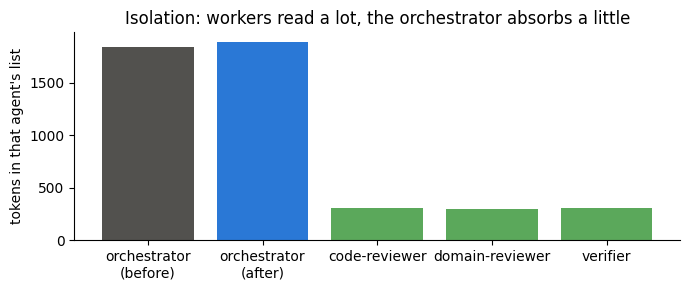

In [8]:
# An orchestrator that has already accumulated a lot of context.
orchestrator_list = [{"role": "user", "content": "Audit this solver end to end."}]
for i in range(8):
    orchestrator_list.append({"role": "assistant",
                              "content": [{"type": "text", "text": f"step {i}: " + "detail " * 60}]})
    orchestrator_list.append({"role": "user",
                              "content": [{"type": "text", "text": "continue " * 40}]})

orch_before = conversation_tokens(orchestrator_list)

worker_lists, summaries = [], []
for name, task in [("code-reviewer", "Check the loop for silent failure."),
                   ("domain-reviewer", "Check the budget constraint."),
                   ("verifier", "Run it and report the exit status.")]:
    wl = [{"role": "user", "content": task}]           # <- fresh, task only
    wl.append({"role": "assistant", "content": [{"type": "text", "text": "analysis " * 120}]})
    worker_lists.append((name, conversation_tokens(wl)))
    summaries.append(f"{name}: one-paragraph finding.")

orchestrator_list.append({"role": "user",
                          "content": [{"type": "text", "text": " ".join(summaries)}]})
orch_after = conversation_tokens(orchestrator_list)

print(f"orchestrator before dispatch : {orch_before:>6} tokens")
print(f"orchestrator after  dispatch : {orch_after:>6} tokens  (+{orch_after-orch_before})")
for name, tok in worker_lists:
    print(f"  worker {name:<16}: {tok:>6} tokens -- never entered the orchestrator's list")

hidden = sum(t for _, t in worker_lists)
print(f"\nwork done out of sight: {hidden:,} tokens")
print(f"cost to the orchestrator's context: {orch_after - orch_before:,} tokens")

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(["orchestrator\n(before)", "orchestrator\n(after)"] + [n for n, _ in worker_lists],
       [orch_before, orch_after] + [t for _, t in worker_lists],
       color=["#52514e", "#2a78d6", "#5ba85b", "#5ba85b", "#5ba85b"])
ax.set_ylabel("tokens in that agent's list")
ax.set_title("Isolation: workers read a lot, the orchestrator absorbs a little")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

> **✏️ Your turn:** raise the workers' analysis length and re-run. The
> orchestrator's growth barely moves. **But** — T5c's warning — all three workers
> were handed *your* framing in their task string. What would make their
> agreement genuinely independent evidence? (Hint: it cannot be fixed by adding
> a fourth worker.)

## Step 7 — Blackboard: shared state instead of message passing

The third wiring. Agents do not talk to each other; they read and write one
store. In a research project that store is usually just **files on disk** —
which is exactly the file-driven workflow of T5b.

In [9]:
blackboard = {}

def post(agent, key, value):
    blackboard[key] = {"by": agent, "value": value}
    print(f"  {agent:<16} wrote {key!r}")

def read(agent, key):
    hit = blackboard.get(key)
    print(f"  {agent:<16} read  {key!r} -> {'miss' if hit is None else hit['value']}")
    return None if hit is None else hit["value"]

print("round 1")
post("analyst", "beta", 0.96)
read("reviewer", "r")                       # not there yet
print("round 2")
post("analyst", "r", 0.041667)
r = read("reviewer", "r")                   # now it is
post("reviewer", "feasible", (1 + r) * 2.0 + 1.0 - 2.1 > 0)

print("\nblackboard:")
for k, v in blackboard.items():
    print(f"  {k:<10} = {str(v['value']):<8} (by {v['by']})")
print("\nNo agent called another. Coordination happened through the store.")

round 1
  analyst          wrote 'beta'
  reviewer         read  'r' -> miss
round 2
  analyst          wrote 'r'
  reviewer         read  'r' -> 0.041667
  reviewer         wrote 'feasible'

blackboard:
  beta       = 0.96     (by analyst)
  r          = 0.041667 (by analyst)
  feasible   = True     (by reviewer)

No agent called another. Coordination happened through the store.


## Step 8 — So how many agents can you actually run?

The quota is denominated in **tokens per minute**, not in agents. This is the
quantitative answer to "how many agents can interact simultaneously".

 avg turn  turns  tokens/agent  agents that fit
    1,000      4         4,000               50
    3,000      6        18,000               11
    8,000     10        80,000                2
   20,000     15       300,000                0

A chatty agent is not 'one agent' -- it is several agents' worth of quota.


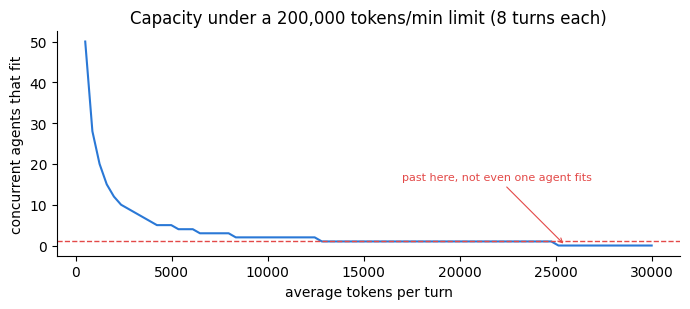

In [10]:
from agent_lab import agents_that_fit

LIMIT = 200_000          # tokens per minute -- check your own plan's actual limit

print(f"{'avg turn':>9} {'turns':>6} {'tokens/agent':>13} {'agents that fit':>16}")
for avg_turn, turns_each in [(1_000, 4), (3_000, 6), (8_000, 10), (20_000, 15)]:
    n = agents_that_fit(LIMIT, avg_turn, turns_each)
    print(f"{avg_turn:>9,} {turns_each:>6} {avg_turn*turns_each:>13,} {n:>16}")

print(f"\nA chatty agent is not 'one agent' -- it is several agents' worth of quota.")

verbosity = np.linspace(500, 30_000, 80)
fits = [agents_that_fit(LIMIT, int(v), 8) for v in verbosity]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(verbosity, fits, color="#2a78d6")
ax.axhline(1, color="#e34948", ls="--", lw=1)
ax.annotate("past here, not even one agent fits",
            xy=(25_500, 0), xytext=(17_000, 16), fontsize=8, color="#e34948",
            arrowprops=dict(arrowstyle="->", color="#e34948", lw=0.8))
ax.set_xlabel("average tokens per turn"); ax.set_ylabel("concurrent agents that fit")
ax.set_title(f"Capacity under a {LIMIT:,} tokens/min limit (8 turns each)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

> **✏️ Your turn:** the rate limit is only the *first* constraint. Add a
> coordination cost: suppose you must read and reconcile every agent's report,
> at 3 minutes each, and you have 30 minutes. How many agents is that? Which
> constraint binds first for you — the vendor's, or your own attention?

That third constraint is the one T3b argues usually binds, and it is the
one no vendor will raise for you.

## Step 9 (optional) — the same loop, live

**Off by default.** This calls the local `claude -p`, so you must have run
`claude` in a terminal and completed `/login` first. **No Anthropic API key is
needed** — it uses your own Claude Code session.

Everything above already ran without it. This step only shows that the stub was
faithful.

In [11]:
ENABLE_LLM = False        # set True only after running `claude` + /login in a terminal

if ENABLE_LLM:
    ok, msg = agent_lab.claude_code_auth_check(timeout=30)
    print("auth check:", "ok" if ok else "failed")
    print(msg)
    if ok:
        answer = agent_lab.claude_code_ask(
            "In one sentence: for CRRA utility with sigma=2, why does failing to "
            "mask c<=0 make a value-function iteration prefer infeasible choices?")
        print("\nlive answer:\n", answer)
else:
    print("Skipped. Set ENABLE_LLM = True to run the optional live comparison.")
    print("Part A is complete without it.")

Skipped. Set ENABLE_LLM = True to run the optional live comparison.
Part A is complete without it.


### For reference: the same loop against the real API

You do **not** need to run this, and `anthropic` is deliberately *not* a
dependency of this course. It is here so you recognise the real surface when
you meet it:

```python
import anthropic
client = anthropic.Anthropic()          # reads ANTHROPIC_API_KEY

messages = [{"role": "user", "content": "..."}]
while True:
    resp = client.messages.create(
        model="claude-opus-5",
        max_tokens=16000,
        system="You are a computational macroeconomist.",
        tools=registry.to_api_list(),   # the SAME schemas from Step 2
        messages=messages,
    )
    if resp.stop_reason != "tool_use":
        break
    messages.append({"role": "assistant", "content": resp.content})
    results = [
        {"type": "tool_result", "tool_use_id": b.id,
         "content": registry.run(b.name, b.input)[0]}
        for b in resp.content if b.type == "tool_use"
    ]
    messages.append({"role": "user", "content": results})
```

Compare it to `agent_lab.run_agent`. They are the same function.

## Part B — now go dispatch real agents

Everything so far simulated the model. **Part B does not.**

Open **`TERMINAL_WALKTHROUGH.md`** and work through it in your terminal. You
will design three specialist agents, point them at a deliberately flawed
Aiyagari solver in `review_target/`, and run the four checks from T3b
— including the decisive one, where you narrow an agent's `description` and
watch dispatch stop.

---

## Discussion prompts

1. Step 4 showed cost growing faster than linearly in turns. Compaction
   summarises old turns to fight this. What does that cost you *epistemically*,
   and how would you detect it had gone wrong?
2. Step 6 showed workers hide their reading from the orchestrator. When is that
   a bug rather than a feature?
3. Steps 5–7 wired the same three agents three ways. For a referee-report
   pipeline, which wiring would you choose, and what would you have to give up?
4. Step 8's binding constraint was your own attention. If a lab gave you an
   unlimited token budget tomorrow, how many agents would you actually run?
5. A colleague says "the system automatically picks the right agent for my
   prompt." After Part B, what one experiment settles whether they are right?

## Reproducibility

Part A is fully deterministic: the model is a fixed script, no RNG is used, and
no network call is made. Re-running the notebook top to bottom reproduces every
number and figure exactly. Part B calls a live model and will **not** reproduce
verbatim — record the date, the CLI version (`claude --version`), and the model
name alongside any output you keep, exactly as T5d's chain-of-custody
frame requires.